# Optimización local: el problema de las 4 reinas

En este ejercicio modelaremos el problema de las **4 reinas** como un problema de optimización y construiremos tres algoritmos:

1. **Hill Climbing**
2. **Hill Climbing con Random Restart**
3. **Simulated Annealing**

La mayor parte de las funciones están incompletas. Deben implementarse durante la clase.

---

## Objetivo

Ubicar cuatro reinas en un tablero $4 \times 4$ de forma que ninguna pareja se ataque.

Una reina ataca a otra si ambas están:

- en la misma fila;
- en la misma columna;
- en la misma diagonal.

## 1. Formulación como problema de optimización

Representaremos un estado mediante un vector:

$$
x = [x_0, x_1, x_2, x_3]
$$

donde $x_i$ indica la **fila** de la reina ubicada en la columna $i$.

Por ejemplo:

$$
x = [1, 3, 0, 2]
$$

representa las posiciones:

$$
(1,0), (3,1), (0,2), (2,3)
$$

Como cada columna contiene exactamente una reina, no pueden existir conflictos por columna.

### Espacio de búsqueda

Cada una de las cuatro reinas puede estar en cualquiera de las cuatro filas:

$$
|\mathcal{X}| = 4^4 = 256
$$

### Función de costo

Definiremos:

$$
C(x) = \text{número de parejas de reinas que se atacan}
$$

El objetivo es resolver:

$$
\min_{x \in \mathcal{X}} C(x)
$$

Una solución válida satisface:

$$
C(x)=0
$$

In [1]:
import math
import random
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["#F0D9B5", "#B58863"])



N = 4
SEED = 42
random.seed(SEED)

## 2. Visualización de un estado

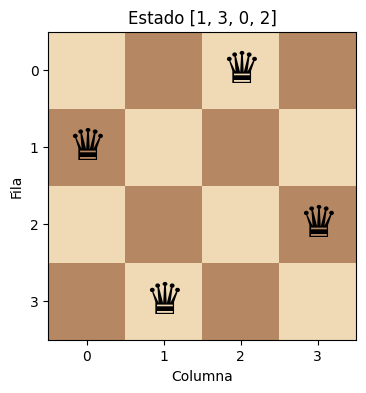

In [2]:
def plot_board(state, title=None):
    """Visualiza un estado del problema de las N reinas."""
    n = len(state)
    board = [[(row + col) % 2 for col in range(n)] for row in range(n)]

    plt.figure(figsize=(4, 4))
    plt.imshow(board, cmap="Greys", vmin=0, vmax=1)

    for col, row in enumerate(state):
        plt.text(col, row, "♛", ha="center", va="center", fontsize=32)

    plt.xticks(range(n))
    plt.yticks(range(n))
    plt.xlabel("Columna")
    plt.ylabel("Fila")
    plt.grid(False)
    if title:
        plt.title(title)

    plt.imshow(board, cmap=cmap)


example_state = [1, 3, 0, 2]
plot_board(example_state, title=f"Estado {example_state}")

## Actividad 1. Detectar conflictos

Dos reinas ubicadas en $(r_i,c_i)$ y $(r_j,c_j)$ se atacan si:

$$
r_i = r_j
$$

o si están en la misma diagonal:

$$
|r_i-r_j| = |c_i-c_j|
$$

Complete la función `attacking`.

In [ ]:
def attacking(row_i, col_i, row_j, col_j):
    if row_i == row_j:
        return True
    if abs(row_i - row_j) == abs(col_i - col_j):
        return True
    return False

In [ ]:
# Pruebas de la actividad 1
assert attacking(0, 0, 0, 3) is True       # misma fila
assert attacking(0, 0, 3, 3) is True       # misma diagonal
assert attacking(0, 0, 1, 3) is False      # no se atacan

print("Pruebas superadas.")

## Actividad 2. Función de costo

Implemente una función que cuente cuántas parejas de reinas se atacan.

Para cuatro reinas existen:

$$
\binom{4}{2}=6
$$

parejas posibles.

In [ ]:
def cost(state):
    n = len(state)
    conflicts = 0
    for i in range(n):
        for j in range(i + 1, n):
            if attacking(state[i], i, state[j], j):
                conflicts += 1
    return conflicts

In [ ]:
# Pruebas de la actividad 2
assert cost([0, 0, 0, 0]) == 6
assert cost([0, 1, 2, 3]) == 6
assert cost([1, 3, 0, 2]) == 0

print("Pruebas superadas.")

## 3. Vecindario

Un vecino se obtiene moviendo **una sola reina** a otra fila de su misma columna.

Para cada una de las $N$ columnas hay $N-1$ movimientos posibles:

$$
|N(x)| = N(N-1)
$$

Para $N=4$:

$$
|N(x)|=4(3)=12
$$

## Actividad 3. Generar los vecinos

Implemente `neighbors(state)`.

La función debe retornar todos los estados que difieren del original en la fila de exactamente una reina.

In [ ]:
def neighbors(state):
    n = len(state)
    result = []
    for col in range(n):
        for row in range(n):
            if row != state[col]:
                new_state = state.copy()
                new_state[col] = row
                result.append(new_state)
    return result

In [ ]:
# Pruebas de la actividad 3
test_state = [0, 1, 2, 3]
test_neighbors = neighbors(test_state)

assert len(test_neighbors) == 12
assert test_state not in test_neighbors
assert len({tuple(s) for s in test_neighbors}) == 12

print("Pruebas superadas.")

## Actividad 4. Mejor vecino

Implemente una función que encuentre el menor costo entre todos los vecinos.

Cuando existan varios vecinos con el mismo costo mínimo, seleccione uno aleatoriamente.

In [ ]:
def best_neighbor(state):
    vecinos = neighbors(state)
    costos = [cost(v) for v in vecinos]
    minimo = min(costos)
    candidatos = [v for v, c in zip(vecinos, costos) if c == minimo]
    elegido = random.choice(candidatos)
    return elegido, minimo

In [ ]:
# Prueba básica
state = [0, 0, 0, 0]
next_state, next_cost = best_neighbor(state)

assert next_state in neighbors(state)
assert next_cost == cost(next_state)
assert next_cost == min(cost(s) for s in neighbors(state))

print("Pruebas superadas.")

## 4. Hill Climbing

Hill Climbing comienza en un estado inicial y se mueve repetidamente hacia un vecino con menor costo.

$$
x_{t+1} = \arg\min_{y \in N(x_t)} C(y)
$$

El algoritmo termina cuando:

- encuentra una solución con costo cero; o
- ningún vecino mejora el estado actual.

Este segundo caso puede corresponder a un **mínimo local** o a una **meseta**.

## Actividad 5. Implementar Hill Climbing

In [ ]:
def hill_climbing(initial_state, max_steps=100):
    current = initial_state
    history = [current]

    for _ in range(max_steps):
        if cost(current) == 0:
            break
        next_state, next_cost = best_neighbor(current)
        if next_cost >= cost(current):
            break
        current = next_state
        history.append(current)

    return current, history

In [ ]:
initial_state = [0, 0, 0, 0]
final_state, history = hill_climbing(initial_state)

print("Estado inicial:", initial_state)
print("Estado final:", final_state)
print("Costo final:", cost(final_state))
print("Número de movimientos:", len(history) - 1)

plot_board(initial_state, "Estado inicial")
plot_board(final_state, f"Estado final — costo {cost(final_state)}")

## Actividad 6. Analizar una ejecución

Grafique el costo de los estados visitados por Hill Climbing.

In [ ]:
def plot_cost_history(history, title="Evolución del costo"):
    costs = [cost(state) for state in history]

    plt.figure(figsize=(7, 4))
    plt.plot(range(len(costs)), costs, marker="o")
    plt.xlabel("Iteración")
    plt.ylabel("Costo")
    plt.title(title)
    plt.xticks(range(len(costs)))
    plt.show()


plot_cost_history(history)

La gráfica muestra una línea descendente, sin subidas: 6, 3, 1, 0. Esto refleja el comportamiento propio de Hill Climbing, donde cada paso mueve al vecino de menor costo, y la búsqueda nunca acepta un movimiento que empeore la solución actual. La curva termina en cero en la última iteración, momento en el que se alcanza un estado sin conflictos entre reinas.

Este resultado en particular llegó a la solución óptima en solo tres pasos, algo que no siempre ocurre. Con otros estados iniciales, la curva puede detenerse en un valor mayor a cero y quedar plana en las últimas iteraciones, señal de que el algoritmo cayó en un mínimo local o una meseta, tal como se discutió en la pregunta 1 y 2 del apartado anterior.

## 5. Hill Climbing con Random Restart

Hill Climbing puede quedar atrapado en mínimos locales.

Random Restart ejecuta Hill Climbing desde diferentes estados iniciales:

$$
x_0^{(1)}, x_0^{(2)}, \ldots, x_0^{(R)}
$$

El algoritmo termina cuando encuentra una solución o cuando agota el número máximo de reinicios.

## Actividad 7. Implementar Random Restart

In [ ]:
def random_state(n=N):
    """Genera un estado aleatorio."""
    return [random.randrange(n) for _ in range(n)]


def random_restart_hill_climbing(max_restarts=50, max_steps=100):
    best_state = None
    best_history = None
    best_cost = None

    for i in range(max_restarts):
        start = random_state()
        state, history = hill_climbing(start, max_steps)
        c = cost(state)

        if best_cost is None or c < best_cost:
            best_state = state
            best_history = history
            best_cost = c

        if best_cost == 0:
            return best_state, best_history, i + 1

    return best_state, best_history, max_restarts

In [ ]:
best_state, best_history, restarts = random_restart_hill_climbing()

print("Mejor estado:", best_state)
print("Costo:", cost(best_state))
print("Reinicios utilizados:", restarts)

plot_board(best_state, f"Random Restart — costo {cost(best_state)}")
plot_cost_history(best_history, "Mejor ejecución de Random Restart")

## 6. Simulated Annealing

Simulated Annealing permite aceptar temporalmente movimientos que empeoran la solución.

Si un vecino tiene costo menor o igual, se acepta.

Si empeora el costo en una cantidad:

$$
\Delta C = C(x') - C(x) > 0
$$

se acepta con probabilidad:

$$
P(\text{aceptar}) = e^{-\Delta C/T}
$$

donde $T$ es la temperatura.

Usaremos un enfriamiento geométrico:

$$
T_{t+1} = \alpha T_t
$$

con $0 < \alpha < 1$.

## Actividad 8. Probabilidad de aceptación

In [ ]:
def acceptance_probability(current_cost, candidate_cost, temperature):
    if candidate_cost <= current_cost:
        return 1.0
    delta = candidate_cost - current_cost
    return math.exp(-delta / temperature)

In [ ]:
assert acceptance_probability(3, 2, 1.0) == 1.0
assert acceptance_probability(3, 3, 1.0) == 1.0

p = acceptance_probability(2, 3, 1.0)
assert math.isclose(p, math.exp(-1), rel_tol=1e-9)

print("Pruebas superadas.")

## Actividad 9. Implementar Simulated Annealing

En cada iteración:

1. seleccione un vecino aleatorio;
2. calcule el cambio de costo;
3. acepte siempre las mejoras;
4. acepte algunos movimientos peores según la temperatura;
5. reduzca la temperatura.

In [ ]:
def simulated_annealing(
    initial_state,
    initial_temperature=10.0,
    cooling_rate=0.95,
    min_temperature=1e-3,
    max_steps=1000,
):
    current = initial_state
    current_cost = cost(current)
    best_state = current
    best_cost = current_cost

    history = [current]
    temperatures = [initial_temperature]

    T = initial_temperature

    for _ in range(max_steps):
        if current_cost == 0 or T < min_temperature:
            break

        candidate = random.choice(neighbors(current))
        candidate_cost = cost(candidate)

        p = acceptance_probability(current_cost, candidate_cost, T)
        if random.random() < p:
            current = candidate
            current_cost = candidate_cost
            history.append(current)
            temperatures.append(T)

            if current_cost < best_cost:
                best_state = current
                best_cost = current_cost

        T = T * cooling_rate

    return best_state, history, temperatures

In [ ]:
initial_state = random_state()
sa_state, sa_history, temperatures = simulated_annealing(initial_state)

print("Estado inicial:", initial_state)
print("Mejor estado:", sa_state)
print("Costo final:", cost(sa_state))
print("Estados aceptados:", len(sa_history))

plot_board(initial_state, "Estado inicial")
plot_board(sa_state, f"Simulated Annealing — costo {cost(sa_state)}")
plot_cost_history(sa_history, "Evolución del costo en Simulated Annealing")

## Actividad 10. Comparación experimental

Ejecute cada algoritmo varias veces y registre su tasa de éxito.

Una ejecución es exitosa cuando encuentra un estado con costo cero.

In [ ]:
def compare_algorithms(trials=100):
    results = {
        "Hill Climbing": 0,
        "Random Restart": 0,
        "Simulated Annealing": 0,
    }

    for _ in range(trials):
        initial_state = random_state()

        hc_state, _ = hill_climbing(initial_state)
        if cost(hc_state) == 0:
            results["Hill Climbing"] += 1

        rr_state, _, _ = random_restart_hill_climbing(max_restarts=20)
        if cost(rr_state) == 0:
            results["Random Restart"] += 1

        sa_state, _, _ = simulated_annealing(initial_state)
        if cost(sa_state) == 0:
            results["Simulated Annealing"] += 1

    return results


# Descomente cuando haya terminado todas las implementaciones.
 results = compare_algorithms(trials=100)
 for algorithm, successes in results.items():
     print(f"{algorithm:20s}: {successes}/100")

## Preguntas de discusión

1. ¿Por qué Hill Climbing puede fallar aunque exista una solución?
El algoritmo solo compara el estado actual con sus vecinos directos. Cuando todos esos vecinos tienen costo igual o mayor, el proceso se detiene ahí, sin importar que en otra parte del espacio de búsqueda exista un estado con costo cero. La búsqueda queda atrapada en esa zona por su naturaleza puramente local.

2. ¿Qué diferencia existe entre una meseta y un mínimo local?
En un mínimo local, todos los vecinos tienen un costo mayor al estado actual, entonces cualquier movimiento empeora la solución. En una meseta, uno o varios vecinos tienen el mismo costo que el estado actual, así que un movimiento lateral no mejora ni empeora nada, y el algoritmo puede quedar dando vueltas entre estados equivalentes sin avanzar.

3. ¿Por qué Random Restart mejora la probabilidad de encontrar una solución?
Cada punto de partida define una región distinta del espacio de búsqueda. Si un intento cae en un mínimo local, otro intento desde un punto diferente tiene la posibilidad de caer en una región sin mínimos locales cercanos y llegar hasta costo cero. Con suficientes reinicios, la probabilidad acumulada de encontrar al menos una buena región crece bastante.

4. ¿Qué ocurre en Simulated Annealing cuando la temperatura es muy alta?
La probabilidad de aceptación, se acerca a 1 incluso para cambios de costo grandes. El algoritmo entonces acepta casi cualquier vecino, mejor o peor, y el recorrido se parece a una caminata aleatoria. Esto ayuda a explorar el espacio, pero al principio no hay presión real hacia soluciones mejores.

5. ¿Qué ocurre si la temperatura disminuye demasiado rápido?
El algoritmo pierde pronto la capacidad de aceptar movimientos peores y termina comportándose como un Hill Climbing normal. Si para ese momento el estado actual está cerca de un mínimo local, la búsqueda queda atrapada ahí igual que en Hill Climbing simple, sin la oportunidad de escapar.

6. ¿Cómo cambiaría el tamaño del espacio de búsqueda para 8 reinas?
Con 𝑁=4 el espacio tiene 4^4=256 estados. Con 𝑁=8 pasa a 8^8=16,777,216 estados, un crecimiento exponencial enorme frente al aumento lineal en el número de reinas. Esto hace que el problema sea mucho más difícil de recorrer por fuerza bruta y resalta la importancia de usar métodos de optimización local.

7. ¿Cuál de los tres algoritmos fue más confiable en los experimentos?
Con N=4, Random Restart y Simulated Annealing quedaron prácticamente empatados, muy por encima de Hill Climbing puro. Con N=8 (ver más abajo) Random Restart se mantiene como el más confiable, porque cada reinicio arranca la búsqueda desde cero en una región distinta del espacio, mientras que Simulated Annealing depende mucho de los parámetros de temperatura elegidos.

## Reto adicional

Modifique:

```python
N = 8
```

y evalúe los algoritmos en el problema de las **8 reinas**.

Compare:

- tasa de éxito;
- número de iteraciones;
- número de reinicios;
- sensibilidad a la temperatura inicial;
- sensibilidad a la tasa de enfriamiento.

In [ ]:
Algoritmo             [Éxitos sobre 100    Promedio movimientos/reinicios]
Hill Climbing:        [13, 3.3]
Random Restart:       [94, 7.6]
Simulated Annealing:  [21, 58]

Tasa de éxito: Random Restart casi no se ve afectado y sigue por encima del 90%. Hill Climbing y Simulated Annealing caen fuerte, a 13% y 21%.

Iteraciones: Hill Climbing termina rápido porque se atasca pronto. Simulated Annealing necesita muchos más pasos porque el enfriamiento es lento y sigue aceptando movimientos por bastante tiempo.

Reinicios: Random Restart pasó de 2.3 reinicios en promedio con 4 reinas a 7.6 con 8 reinas. Cuesta más, pero sigue siendo manejable.

Temperatura inicial: Probé con varios valores de temperatura inicial para Simulated Annealing. Con temperaturas bajas la tasa de éxito se queda corta porque hay poca exploración al inicio. Con una temperatura intermedia el resultado mejora. Con una temperatura muy alta vuelve a bajar un poco, porque toma más tiempo llegar a la etapa donde el algoritmo empieza a afinar la solución.

Tasa de enfriamiento: Este fue el parámetro que más cambió los resultados. Con enfriamiento rápido el algoritmo casi no encuentra soluciones. Con enfriamiento lento el éxito sube bastante, porque el algoritmo pasa más tiempo en el rango de temperaturas donde mejor equilibra exploración con mejora de la solución.

Así, para 8 reinas, Random Restart resultó el más confiable y el que menos depende de ajustar parámetros. Simulated Annealing puede funcionar bien, pero necesita una temperatura inicial y sobre todo un enfriamiento bien calibrados; si enfría muy rápido, cae en el mismo problema que Hill Climbing solo.

Así, para 8 reinas, Random Restart resultó el más confiable y el que menos depende de ajustar parámetros. Simulated Annealing puede funcionar bien, pero necesita una temperatura inicial y sobre todo un enfriamiento bien calibrados; si enfría muy rápido, cae en el mismo problema que Hill Climbing solo.